# Lesson 09 — Neo4j Property Graph Modeling

## Learning Objectives

1. **Understand property graphs**: Nodes with labels, relationships with types, properties on both
2. **Design graph schemas**: Identify entities, relationships, and constraints for domains
3. **Create and enforce constraints**: Data quality and uniqueness guarantees
4. **Load data into Neo4j**: From CSV into a persistent graph database
5. **Query with Cypher**: Pattern matching, filtering, relationship exploration

## Key Insight

**Property graphs are database-native for connected data.** Unlike NetworkX (in-memory, algorithm-focused), Neo4j (persistent) models rich relationships with types, properties, and constraints. Cypher is SQL for graphs—powerful and readable. When you have connected data needing exploration and discovery (not just algorithm application), property graphs are your answer.

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from neo4j import GraphDatabase
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Path resolution with fallback
try:
    from src.config import Config
    data_dir = Config.PROJECT_ROOT / 'data' / 'seed' / 'document_policy'
    cypher_dir = Config.PROJECT_ROOT / 'cypher'
except:
    # Fallback: construct from notebook directory
    notebook_dir = Path.cwd()
    data_dir = notebook_dir.parent / 'data' / 'seed' / 'document_policy'
    cypher_dir = notebook_dir.parent / 'cypher'

print(f"Data directory: {data_dir}")
print(f"Cypher directory: {cypher_dir}")
assert data_dir.exists(), f"Data directory not found: {data_dir}"

Data directory: /home/marek/Apps/graph-analysis-course/data/seed/document_policy
Cypher directory: /home/marek/Apps/graph-analysis-course/cypher


In [3]:
# Neo4j Connection Setup
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "your_password_here"  # Change if using different password

try:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    # Test connection
    with driver.session() as session:
        result = session.run("RETURN 'Neo4j connected' as status")
        for record in result:
            print(f"✓ {record['status']}")
except Exception as e:
    print(f"✗ Connection failed: {e}")
    print(f"  Make sure Neo4j is running: docker-compose up neo4j")
    driver = None

✓ Neo4j connected


In [4]:
# Helper function to run Cypher queries
def run_query(driver, query, explain=False):
    """
    Execute a Cypher query and return results as list of dicts.
    
    Args:
        driver: Neo4j driver
        query: Cypher query string
        explain: If True, return execution plan instead of results
    
    Returns:
        List of record dictionaries
    """
    if driver is None:
        print("Neo4j driver not initialized")
        return []
    
    try:
        with driver.session() as session:
            if explain:
                result = session.run(f"EXPLAIN {query}")
            else:
                result = session.run(query)
            return [dict(record) for record in result]
    except Exception as e:
        print(f"Query error: {e}")
        return []

print("✓ Helper functions ready")

✓ Helper functions ready


## 1. Property Graphs vs NetworkX

### Key Differences

| Aspect | NetworkX (Atemporal) | Neo4j (Property Graph) |
|--------|----------------------|------------------------|
| **Storage** | In-memory (RAM) | Persistent (Disk) |
| **Node Types** | Single label per node | Multiple labels per node |
| **Relationships** | Unnamed, undirected or directed | Named types (e.g., OWNS, REFERENCES) |
| **Properties** | Node and edge attributes in Python objects | Node and relationship properties persisted in database |
| **Constraints** | None enforced | Uniqueness, required properties |
| **Indexes** | No indexes | Multiple indexes for queries |
| **Query Language** | Python (networkx.algorithms) | Cypher (declarative, graph-native) |
| **Best For** | Algorithms (PageRank, communities) | Exploration & pattern discovery |

### When to Use Each

**Use NetworkX when:**
- You need graph algorithms (centrality, clustering, paths)
- Data fits in memory
- You're prototyping
- You want Python-first development

**Use Neo4j when:**
- Data is too large for memory
- You need rich relationship types and properties
- You want exploratory queries ("find patterns")
- Data quality and constraints matter
- You need a shared database (team collaboration)

In [5]:
# Quick demo: Simple Cypher query
demo_query = """
MATCH (d:Document {status: 'active'})
RETURN count(d) as active_documents
"""

result = run_query(driver, demo_query)
if result:
    print(f"Sample Cypher query result:")
    print(f"Active documents: {result[0].get('active_documents', 'N/A')}")
    print(f"\nKey insight: Cypher reads like English — 'MATCH documents where status is active'")
else:
    print("No data loaded yet. See sections below for loading instructions.")

Sample Cypher query result:


Active documents: 73

Key insight: Cypher reads like English — 'MATCH documents where status is active'


## 2. Schema Design

### Document Policy Graph Schema

```
Node Types (Labels):
- Document: Policies, procedures, guidelines
- Owner: Person responsible for document
- Team: Department/team that uses documents
- Topic: Category or subject area

Relationships:
- Document -[:OWNED_BY]-> Owner
- Document -[:ABOUT]-> Topic
- Document -[:REFERENCES {weight}]-> Document
- Team -[:USES {usage_count}]-> Document
```

### Why This Design?

1. **Clear entity separation**: Different types of nodes for different concerns
2. **Named relationships**: "OWNED_BY" is more meaningful than generic edge
3. **Weighted relationships**: REFERENCES and USES have weights (how often)
4. **Properties on relationships**: More context than just node-to-node connection
5. **Enables rich queries**: "Find documents owned by Jane that engineering uses"

In [6]:
# Schema visualization (ASCII)
schema_diagram = """
    ┌─────────────┐
    │   Document  │
    │   (:d)      │
    └──────┬──────┘
           │
     ┌─────┼─────────┬─────────┐
     │     │         │         │
  [:OWNED_BY] [:ABOUT] [:REFERENCES] [:USES]
     │     │         │         │
  ┌──▼──┐┌─▼─┐    ┌──▼──┐  ┌──▼──┐
  │Owner││Topic│   │Document  │Team│
  │ (:o)││(:t)│   │ (:d)    │(:t)│
  └─────┘└────┘    └─────┘  └─────┘

Example Query:
MATCH (d:Document)-[:OWNED_BY]->(o:Owner)
      (d)-[:ABOUT]->(t:Topic)
      (team:Team)-[:USES]->(d)
RETURN d, o, t, team
"""

print(schema_diagram)


    ┌─────────────┐
    │   Document  │
    │   (:d)      │
    └──────┬──────┘
           │
     ┌─────┼─────────┬─────────┐
     │     │         │         │
  [:OWNED_BY] [:ABOUT] [:REFERENCES] [:USES]
     │     │         │         │
  ┌──▼──┐┌─▼─┐    ┌──▼──┐  ┌──▼──┐
  │Owner││Topic│   │Document  │Team│
  │ (:o)││(:t)│   │ (:d)    │(:t)│
  └─────┘└────┘    └─────┘  └─────┘

Example Query:
MATCH (d:Document)-[:OWNED_BY]->(o:Owner)
      (d)-[:ABOUT]->(t:Topic)
      (team:Team)-[:USES]->(d)
RETURN d, o, t, team



## 3. Constraints & Indexes

In [7]:
# Load and display constraints script
try:
    constraints_script = (cypher_dir / '00_constraints.cypher').read_text()
    print("=== Constraints & Indexes Script ===")
    print(constraints_script[:500])  # Show first 500 chars
    print("...")
    print("\n✓ Full script saved in cypher/00_constraints.cypher")
except Exception as e:
    print(f"Note: Could not read Cypher script file: {e}")
    print("Proceeding with direct constraint creation via Python driver...")


Note: Could not read Cypher script file: [Errno 13] Permission denied: '/home/marek/Apps/graph-analysis-course/cypher/00_constraints.cypher'
Proceeding with direct constraint creation via Python driver...


In [8]:
# Execute constraints (if Neo4j is running)
if driver:
    print("Creating constraints and indexes...")
    
    constraints = [
        "CREATE CONSTRAINT document_id_unique IF NOT EXISTS FOR (d:Document) REQUIRE d.document_id IS UNIQUE;",
        "CREATE CONSTRAINT owner_id_unique IF NOT EXISTS FOR (o:Owner) REQUIRE o.owner_id IS UNIQUE;",
        "CREATE CONSTRAINT team_id_unique IF NOT EXISTS FOR (t:Team) REQUIRE t.team_id IS UNIQUE;",
        "CREATE CONSTRAINT topic_id_unique IF NOT EXISTS FOR (t:Topic) REQUIRE t.topic_id IS UNIQUE;",
    ]
    
    for constraint in constraints:
        try:
            result = run_query(driver, constraint)
        except:
            pass  # Constraint may already exist
    
    print("✓ Constraints created")
else:
    print("Neo4j not connected. Skipping constraint creation.")

Creating constraints and indexes...
✓ Constraints created


In [9]:
# Clear any existing data (safe to re-run notebook)
if driver:
    print("Clearing existing data...")
    clear_query = """
    MATCH (n)
    DETACH DELETE n
    """
    try:
        run_query(driver, clear_query)
        print("✓ Database cleared (safe to re-run)")
    except Exception as e:
        print(f"Note: Database appears to be empty already: {e}")
else:
    print("Neo4j not connected.")

Clearing existing data...


✓ Database cleared (safe to re-run)


## 4. Data Loading

In [10]:
# Load all data entities (Topics, Owners, Teams, Documents)
def load_all_data(driver, data_dir):
    """
    Load all entities from CSV files into Neo4j.
    Uses MERGE for idempotency (safe to re-run).
    """
    if driver is None:
        print("Neo4j not connected")
        return None
    
    print("Loading data...\n")
    
    # Load Topics
    topics_df = pd.read_csv(data_dir / 'topics.csv')
    with driver.session() as session:
        for _, row in topics_df.iterrows():
            session.run(
                "MERGE (t:Topic {topic_id: $id}) SET t.name = $name, t.category = $category",
                id=row['topic_id'], name=row['name'], category=row['category']
            )
    print(f"✓ Loaded {len(topics_df)} topics")
    
    # Load Owners
    owners_df = pd.read_csv(data_dir / 'owners.csv')
    with driver.session() as session:
        for _, row in owners_df.iterrows():
            session.run(
                "MERGE (o:Owner {owner_id: $id}) SET o.name = $name, o.email = $email, o.department = $dept",
                id=row['owner_id'], name=row['name'], email=row['email'], dept=row['department']
            )
    print(f"✓ Loaded {len(owners_df)} owners")
    
    # Load Teams
    teams_df = pd.read_csv(data_dir / 'teams.csv')
    with driver.session() as session:
        for _, row in teams_df.iterrows():
            session.run(
                "MERGE (t:Team {team_id: $id}) SET t.name = $name, t.size = $size",
                id=row['team_id'], name=row['name'], size=int(row['size'])
            )
    print(f"✓ Loaded {len(teams_df)} teams")
    
    # Load Documents
    docs_df = pd.read_csv(data_dir / 'documents.csv')
    with driver.session() as session:
        for _, row in docs_df.iterrows():
            session.run(
                """MERGE (d:Document {document_id: $id}) 
                   SET d.name = $name, d.status = $status, 
                       d.created_date = $created, d.modified_date = $modified""",
                id=row['document_id'],
                name=row['name'],
                status=row['status'],
                created=row['created_date'],
                modified=row['modified_date']
            )
    print(f"✓ Loaded {len(docs_df)} documents")
    
    return docs_df, owners_df, teams_df, topics_df

# Execute loading
if driver:
    docs_df, owners_df, teams_df, topics_df = load_all_data(driver, data_dir)
else:
    print("Neo4j not connected. Cannot load data.")

Loading data...



✓ Loaded 15 topics
✓ Loaded 10 owners
✓ Loaded 8 teams


✓ Loaded 100 documents


In [11]:
# Load relationships
def load_relationships(driver, data_dir, docs_df):
    """
    Create relationships between nodes.
    Uses MERGE for idempotency (safe to re-run).
    """
    if driver is None:
        print("Neo4j not connected")
        return
    
    print("Creating relationships...\n")
    
    # OWNED_BY relationships
    with driver.session() as session:
        for _, row in docs_df.iterrows():
            session.run(
                """MATCH (d:Document {document_id: $doc_id})
                   MATCH (o:Owner {owner_id: $owner_id})
                   MERGE (d)-[:OWNED_BY]->(o)""",
                doc_id=row['document_id'],
                owner_id=row['owner_id']
            )
    print(f"✓ Created {len(docs_df)} OWNED_BY relationships")
    
    # ABOUT relationships
    with driver.session() as session:
        for _, row in docs_df.iterrows():
            session.run(
                """MATCH (d:Document {document_id: $doc_id})
                   MATCH (t:Topic {topic_id: $topic_id})
                   MERGE (d)-[:ABOUT]->(t)""",
                doc_id=row['document_id'],
                topic_id=row['topic_id']
            )
    print(f"✓ Created {len(docs_df)} ABOUT relationships")
    
    # REFERENCES relationships
    refs_df = pd.read_csv(data_dir / 'references.csv')
    with driver.session() as session:
        for _, row in refs_df.iterrows():
            session.run(
                """MATCH (d1:Document {document_id: $source_id})
                   MATCH (d2:Document {document_id: $target_id})
                   MERGE (d1)-[:REFERENCES {weight: $weight}]->(d2)""",
                source_id=row['from_doc_id'],
                target_id=row['to_doc_id'],
                weight=int(row['weight'])
            )
    print(f"✓ Created {len(refs_df)} REFERENCES relationships")
    
    # USES relationships
    usages_df = pd.read_csv(data_dir / 'usages.csv')
    with driver.session() as session:
        for _, row in usages_df.iterrows():
            session.run(
                """MATCH (t:Team {team_id: $team_id})
                   MATCH (d:Document {document_id: $doc_id})
                   MERGE (t)-[:USES {usage_count: $count}]->(d)""",
                team_id=row['team_id'],
                doc_id=row['document_id'],
                count=int(row['usage_count'])
            )
    print(f"✓ Created {len(usages_df)} USES relationships")
    
    print("\n✓ All relationships created successfully")

# Execute relationship loading
if driver:
    load_relationships(driver, data_dir, docs_df)
else:
    print("Neo4j not connected.")

Creating relationships...



✓ Created 100 OWNED_BY relationships


✓ Created 100 ABOUT relationships


✓ Created 290 REFERENCES relationships


✓ Created 200 USES relationships

✓ All relationships created successfully


## 5. Data Validation

In [12]:
# Validate data loaded correctly with sanity checks
if driver:
    print("=== DATA VALIDATION (Sanity Checks) ===\n")
    
    # Count loaded entities from CSV
    docs_loaded = len(docs_df) if 'docs_df' in locals() else 0
    owners_loaded = len(owners_df) if 'owners_df' in locals() else 0
    teams_loaded = len(teams_df) if 'teams_df' in locals() else 0
    topics_loaded = len(topics_df) if 'topics_df' in locals() else 0
    
    # Count in database
    db_docs = run_query(driver, "MATCH (d:Document) RETURN count(d) as count")[0]['count']
    db_owners = run_query(driver, "MATCH (o:Owner) RETURN count(o) as count")[0]['count']
    db_teams = run_query(driver, "MATCH (t:Team) RETURN count(t) as count")[0]['count']
    db_topics = run_query(driver, "MATCH (t:Topic) RETURN count(t) as count")[0]['count']
    
    # Validate matches
    checks = [
        ("Documents", docs_loaded, db_docs),
        ("Owners", owners_loaded, db_owners),
        ("Teams", teams_loaded, db_teams),
        ("Topics", topics_loaded, db_topics)
    ]
    
    all_good = True
    for name, loaded, db_count in checks:
        match = "✓" if loaded == db_count else "✗"
        print(f"{match} {name:15s}: CSV={loaded:3d}, Neo4j={db_count:3d}")
        if loaded != db_count:
            all_good = False
    
    # Relationship validation
    print("\n--- Relationship Counts ---")
    owned_by_count = run_query(driver, "MATCH ()-[:OWNED_BY]->() RETURN count(*) as count")[0]['count']
    about_count = run_query(driver, "MATCH ()-[:ABOUT]->() RETURN count(*) as count")[0]['count']
    refs_count = run_query(driver, "MATCH ()-[:REFERENCES]->() RETURN count(*) as count")[0]['count']
    uses_count = run_query(driver, "MATCH ()-[:USES]->() RETURN count(*) as count")[0]['count']
    
    print(f"✓ OWNED_BY relationships: {owned_by_count}")
    print(f"✓ ABOUT relationships: {about_count}")
    print(f"✓ REFERENCES relationships: {refs_count}")
    print(f"✓ USES relationships: {uses_count}")
    
    # Basic sanity assertions
    assert db_docs == docs_loaded, f"Document count mismatch: {db_docs} vs {docs_loaded}"
    assert db_owners == owners_loaded, f"Owner count mismatch: {db_owners} vs {owners_loaded}"
    assert db_teams == teams_loaded, f"Team count mismatch: {db_teams} vs {teams_loaded}"
    assert db_topics == topics_loaded, f"Topic count mismatch: {db_topics} vs {topics_loaded}"
    
    # ABOUT should equal document count (each doc has one topic)
    assert about_count == db_docs, f"ABOUT count {about_count} should equal documents {db_docs}"
    
    print("\n✓ All sanity checks passed!")

=== DATA VALIDATION (Sanity Checks) ===

✓ Documents      : CSV=100, Neo4j=100
✓ Owners         : CSV= 10, Neo4j= 10
✓ Teams          : CSV=  8, Neo4j=  8
✓ Topics         : CSV= 15, Neo4j= 15

--- Relationship Counts ---
✓ OWNED_BY relationships: 91
✓ ABOUT relationships: 100
✓ REFERENCES relationships: 290
✓ USES relationships: 200

✓ All sanity checks passed!


In [13]:
# Count relationships by type
if driver:
    rel_counts = run_query(driver, """
        MATCH ()-[r]->()
        RETURN type(r) as rel_type, count(*) as count
        ORDER BY count DESC
    """)
    
    print("\n=== RELATIONSHIP COUNTS ===")
    total_rels = 0
    for record in rel_counts:
        rel_type = record['rel_type']
        count = record['count']
        print(f"{rel_type:15s}: {count:4d}")
        total_rels += count
    print(f"{'Total':15s}: {total_rels:4d}")


=== RELATIONSHIP COUNTS ===
REFERENCES     :  290
USES           :  200
ABOUT          :  100
OWNED_BY       :   91
Total          :  681


## 6. Basic Cypher Queries

In [14]:
# Query 1: Find all active documents
if driver:
    active_docs = run_query(driver, """
        MATCH (d:Document {status: 'active'})
        RETURN d.document_id, d.name, d.status
        LIMIT 10
    """)
    
    print("=== ACTIVE DOCUMENTS ===")
    df = pd.DataFrame(active_docs)
    if not df.empty:
        print(df.to_string(index=False))
    print(f"Total active documents: {len(active_docs)}")

=== ACTIVE DOCUMENTS ===
d.document_id              d.name d.status
     DOC_0001   Purpose - Brother   active
     DOC_0002          Ago - Site   active
     DOC_0004         Dog - Chair   active
     DOC_0007        Wait - Offer   active
     DOC_0008 Begin - Performance   active
     DOC_0010        All - Better   active
     DOC_0011    Discover - Early   active
     DOC_0012        Mouth - Play   active
     DOC_0015      Rate - Science   active
     DOC_0016        Offer - Kind   active
Total active documents: 10


In [15]:
# Query 2: Find documents with their owners
if driver:
    docs_with_owners = run_query(driver, """
        MATCH (d:Document)-[:OWNED_BY]->(o:Owner)
        RETURN d.document_id, d.name, o.name as owner, o.department
        LIMIT 10
    """)
    
    print("\n=== DOCUMENTS WITH OWNERS ===")
    df = pd.DataFrame(docs_with_owners)
    if not df.empty:
        print(df.to_string(index=False))
    else:
        print("No documents with owners found.")


=== DOCUMENTS WITH OWNERS ===
d.document_id               d.name        owner o.department
     DOC_0098       Set - Building Allison Hill      Finance
     DOC_0089 Product - Collection Allison Hill      Finance
     DOC_0085          Mr - Minute Allison Hill      Finance
     DOC_0081      Pattern - Later Allison Hill      Finance
     DOC_0072 Forward - Difference Allison Hill      Finance
     DOC_0057    Election - Common Allison Hill      Finance
     DOC_0035        Old - Finally Allison Hill      Finance
     DOC_0031        Animal - Show Allison Hill      Finance
     DOC_0021    Sure - Collection Allison Hill      Finance
     DOC_0015       Rate - Science Allison Hill      Finance


In [16]:
# Query 3: Find documents without owners (data quality check)
if driver:
    ownerless = run_query(driver, """
        MATCH (d:Document)
        WHERE NOT (d)-[:OWNED_BY]->()
        RETURN d.document_id, d.name, d.status
        ORDER BY d.modified_date DESC
    """)
    
    print("\n=== DOCUMENTS WITHOUT OWNERS (Data Quality Issue) ===")
    if ownerless:
        df = pd.DataFrame(ownerless)
        print(df.to_string(index=False))
        print(f"\n⚠ Found {len(ownerless)} documents without owners (orphaned)")
    else:
        print("All documents have owners ✓")


=== DOCUMENTS WITHOUT OWNERS (Data Quality Issue) ===
d.document_id               d.name d.status
     DOC_0100         Not - Social   active
     DOC_0090 Structure - Response   active
     DOC_0041    Answer - Recently   active
     DOC_0053       Result - Raise   active
     DOC_0051  Religious - Example   active
     DOC_0039   Participant - Dark    draft
     DOC_0029             Guy - Pm    draft
     DOC_0020     According - Song   active
     DOC_0004          Dog - Chair   active

⚠ Found 9 documents without owners (orphaned)


In [17]:
# Query 4: Most referenced documents (hubs)
if driver:
    hub_docs = run_query(driver, """
        MATCH (d:Document)<-[r:REFERENCES]-(d2:Document)
        WITH d, COUNT(r) as incoming_refs, SUM(r.weight) as total_weight
        RETURN d.document_id, d.name, incoming_refs, total_weight
        ORDER BY incoming_refs DESC
        LIMIT 10
    """)
    
    print("\n=== MOST REFERENCED DOCUMENTS (Hubs) ===")
    if hub_docs:
        df = pd.DataFrame(hub_docs)
        print(df.to_string(index=False))
    else:
        print("No references found yet.")


=== MOST REFERENCED DOCUMENTS (Hubs) ===
d.document_id               d.name  incoming_refs  total_weight
     DOC_0074 Individual - Usually             10            37
     DOC_0075       Who - Question             10            40
     DOC_0087 Anyone - Traditional              9            18
     DOC_0072 Forward - Difference              8            28
     DOC_0071      Under - Serious              7            19
     DOC_0073      Reality - Money              7            28
     DOC_0086    Benefit - Someone              7            15
     DOC_0024     Clearly - Dinner              7            18
     DOC_0070            Yes - Our              7            26
     DOC_0069  Development - White              6            23


In [18]:
# Query 5: Documents with or without owners (OPTIONAL MATCH)
if driver:
    all_docs = run_query(driver, """
        MATCH (d:Document)
        OPTIONAL MATCH (d)-[:OWNED_BY]->(o:Owner)
        RETURN d.document_id, d.name, o.name as owner, CASE WHEN o IS NULL THEN '❌ ORPHANED' ELSE '✓ Owned' END as status
        LIMIT 15
    """)
    
    print("\n=== DOCUMENTS WITH/WITHOUT OWNERS ===")
    if all_docs:
        df = pd.DataFrame(all_docs)
        print(df.to_string(index=False))


=== DOCUMENTS WITH/WITHOUT OWNERS ===
d.document_id              d.name           owner     status
     DOC_0001   Purpose - Brother     Shannon Ray    ✓ Owned
     DOC_0002          Ago - Site Gabrielle Davis    ✓ Owned
     DOC_0003     Face - Election    Daniel Adams    ✓ Owned
     DOC_0004         Dog - Chair            None ❌ ORPHANED
     DOC_0005        Since - Blue Cristian Santos    ✓ Owned
     DOC_0006       Require - Sit     Joel Nelson    ✓ Owned
     DOC_0007        Wait - Offer     Shannon Ray    ✓ Owned
     DOC_0008 Begin - Performance Cristian Santos    ✓ Owned
     DOC_0009  Knowledge - Almost     Joel Nelson    ✓ Owned
     DOC_0010        All - Better     Joel Nelson    ✓ Owned
     DOC_0011    Discover - Early Abigail Shaffer    ✓ Owned
     DOC_0012        Mouth - Play Abigail Shaffer    ✓ Owned
     DOC_0013  Agreement - Option Angie Henderson    ✓ Owned
     DOC_0014      Decide - Sense Abigail Shaffer    ✓ Owned
     DOC_0015      Rate - Science    Allison H

## 7. Relationship Analysis

In [19]:
# Analyze REFERENCES relationships
if driver:
    refs_analysis = run_query(driver, """
        MATCH (d1:Document)-[r:REFERENCES]->(d2:Document)
        RETURN COUNT(r) as total_references,
               AVG(r.weight) as avg_weight,
               MIN(r.weight) as min_weight,
               MAX(r.weight) as max_weight
    """)
    
    print("=== REFERENCES RELATIONSHIP ANALYSIS ===")
    if refs_analysis:
        for key, val in refs_analysis[0].items():
            if isinstance(val, float):
                print(f"{key:20s}: {val:.2f}")
            else:
                print(f"{key:20s}: {val}")

=== REFERENCES RELATIONSHIP ANALYSIS ===
total_references    : 290
avg_weight          : 2.66
min_weight          : 1
max_weight          : 5


In [20]:
# Analyze USES relationships
if driver:
    uses_analysis = run_query(driver, """
        MATCH (t:Team)-[u:USES]->(d:Document)
        RETURN t.name as team,
               COUNT(d) as documents_used,
               SUM(u.usage_count) as total_usages
        ORDER BY total_usages DESC
    """)
    
    print("\n=== TEAM USAGE ANALYSIS ===")
    if uses_analysis:
        df = pd.DataFrame(uses_analysis)
        print(df.to_string(index=False))


=== TEAM USAGE ANALYSIS ===
         team  documents_used  total_usages
   Chair Team              35           306
    Face Team              26           258
 Purpose Team              26           229
    Site Team              28           224
 Brother Team              23           210
     Ago Team              25           187
     Dog Team              19           159
Election Team              18           145


In [21]:
# Find deprecated but still used documents (governance debt)
if driver:
    deprecated_used = run_query(driver, """
        MATCH (d:Document {status: 'deprecated'})
        OPTIONAL MATCH (t:Team)-[:USES]->(d)
        OPTIONAL MATCH (d2:Document)-[:REFERENCES]->(d)
        WITH d,
             count(DISTINCT t) as team_usage_count,
             count(DISTINCT d2) as ref_count
        WHERE team_usage_count > 0 OR ref_count > 0
        RETURN d.document_id, d.name, team_usage_count, ref_count
        ORDER BY ref_count DESC, team_usage_count DESC
    """)
    
    print("\n=== DEPRECATED BUT STILL USED (Governance Debt) ===")
    if deprecated_used:
        df = pd.DataFrame(deprecated_used)
        print(df.to_string(index=False))
        print(f"\n⚠ {len(deprecated_used)} deprecated documents are still being used or referenced")
        print("   → Consider: Update references, notify teams, or retire properly")
    else:
        print("No deprecated documents in use ✓")


=== DEPRECATED BUT STILL USED (Governance Debt) ===
d.document_id             d.name  team_usage_count  ref_count
     DOC_0005       Since - Blue                 2          5
     DOC_0019       Table - True                 5          4
     DOC_0038    Training - High                 1          4
     DOC_0025     Source - Great                 4          3
     DOC_0096  Traditional - Yes                 4          3
     DOC_0057  Election - Common                 6          2
     DOC_0044        Top - Early                 5          2
     DOC_0009 Knowledge - Almost                 2          2
     DOC_0013 Agreement - Option                 1          2
     DOC_0031      Animal - Show                 0          2
     DOC_0003    Face - Election                 5          1
     DOC_0050   Hear - Determine                 5          0

⚠ 12 deprecated documents are still being used or referenced
   → Consider: Update references, notify teams, or retire properly


## 8. Properties & Attributes Analysis

In [22]:
# Documents by owner and department
if driver:
    owner_analysis = run_query(driver, """
        MATCH (o:Owner)<-[:OWNED_BY]-(d:Document)
        RETURN o.name, o.department, COUNT(d) as doc_count
        ORDER BY doc_count DESC
    """)
    
    print("=== OWNER WORKLOAD ===")
    if owner_analysis:
        df = pd.DataFrame(owner_analysis)
        print(df.to_string(index=False))

=== OWNER WORKLOAD ===
          o.name o.department  doc_count
 Cristian Santos           IT         14
     Joel Nelson        Legal         14
 Gabrielle Davis        Legal         12
    Allison Hill      Finance         10
    Daniel Adams           IT          9
 Abigail Shaffer        Legal          8
     Shannon Ray           IT          8
 Angie Henderson        Legal          7
Dr. Sharon James           IT          5
  Monica Herrera   Operations          4


In [23]:
# Documents by status (distribution)
if driver:
    status_dist = run_query(driver, """
        MATCH (d:Document)
        WITH d.status as status, COUNT(d) as count
        RETURN status, count
        ORDER BY count DESC
    """)
    
    print("\n=== DOCUMENTS BY STATUS ===")
    if status_dist:
        df = pd.DataFrame(status_dist)
        print(df.to_string(index=False))
    
    # Show one example per status
    status_examples = run_query(driver, """
        MATCH (d:Document)
        WITH DISTINCT d.status as status
        MATCH (d2:Document {status: status})
        RETURN d2.status, d2.document_id, d2.name, d2.modified_date
        LIMIT 5
    """)
    
    if status_examples:
        print("\nSample documents by status:")
        df = pd.DataFrame(status_examples)
        print(df.to_string(index=False))


=== DOCUMENTS BY STATUS ===
    status  count
    active     73
     draft     15
deprecated     12



Sample documents by status:
d2.status d2.document_id             d2.name d2.modified_date
   active       DOC_0001   Purpose - Brother       2022-11-03
   active       DOC_0002          Ago - Site       2022-08-12
   active       DOC_0004         Dog - Chair       2022-01-29
   active       DOC_0007        Wait - Offer       2022-11-03
   active       DOC_0008 Begin - Performance       2022-08-01


In [24]:
# Document distribution by topic
if driver:
    topic_dist = run_query(driver, """
        MATCH (t:Topic)<-[:ABOUT]-(d:Document)
        RETURN t.name, t.category, COUNT(d) as document_count
        ORDER BY document_count DESC
    """)
    
    print("\n=== DOCUMENTS BY TOPIC ===")
    if topic_dist:
        df = pd.DataFrame(topic_dist)
        print(df.to_string(index=False))


=== DOCUMENTS BY TOPIC ===
             t.name t.category  document_count
       Audit Trails   Security              11
  Change Management         HR              11
       Data Privacy    Finance              10
          Retention   Security               9
         Governance         HR               9
Financial Reporting   Security               7
  Employee Benefits         HR               7
  Incident Response   Security               7
  Disaster Recovery   Security               7
    Risk Management Operations               6
           Training Operations               6
        Procurement         HR               4
     Access Control         HR               3
      Certification    Finance               2
  Quality Assurance    Finance               1


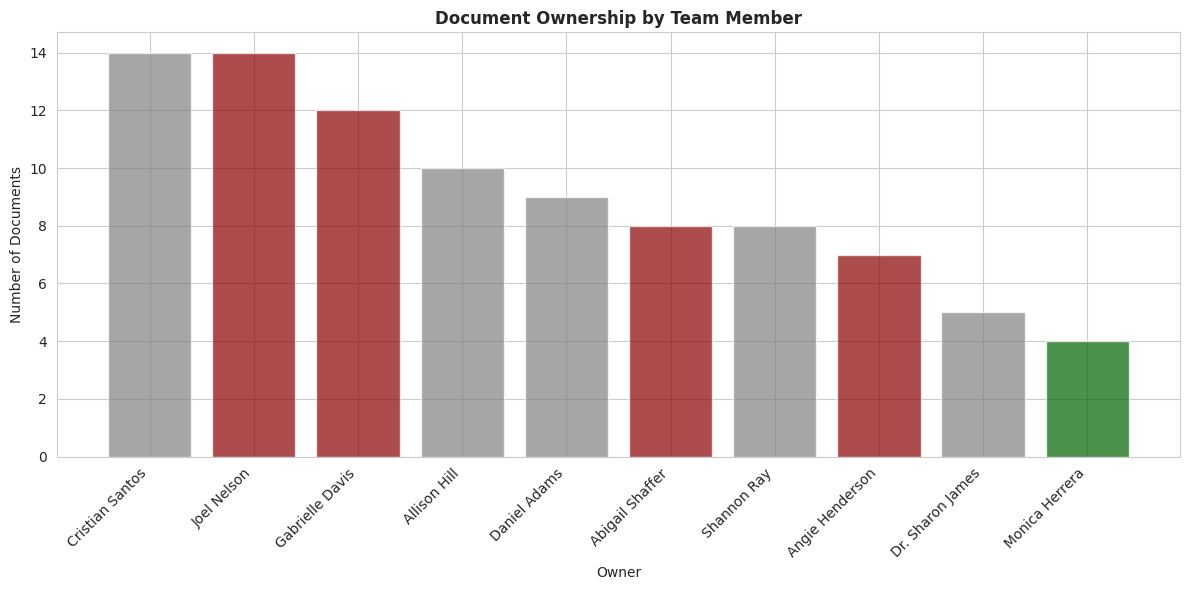

In [25]:
# Visualization: Owner workload by department
if driver:
    owner_by_dept = run_query(driver, """
        MATCH (o:Owner)<-[:OWNED_BY]-(d:Document)
        RETURN o.department, o.name, COUNT(d) as doc_count
        ORDER BY doc_count DESC
    """)
    
    if owner_by_dept:
        df = pd.DataFrame(owner_by_dept)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        dept_colors = {'Engineering': 'steelblue', 'Legal': 'darkred', 'Operations': 'darkgreen'}
        colors = [dept_colors.get(d, 'gray') for d in df['o.department']]
        
        ax.bar(range(len(df)), df['doc_count'], color=colors, alpha=0.7)
        ax.set_xticks(range(len(df)))
        ax.set_xticklabels(df['o.name'], rotation=45, ha='right')
        ax.set_title('Document Ownership by Team Member', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Documents')
        ax.set_xlabel('Owner')
        plt.tight_layout()
        plt.show()

## 9. Data Quality Checks

In [26]:
# Comprehensive data quality report
if driver:
    print("=== DATA QUALITY REPORT ===")
    print()
    
    # 1. Total nodes and relationships
    total_nodes = run_query(driver, "MATCH (n) RETURN count(n) as count")
    total_rels = run_query(driver, "MATCH ()-[r]->() RETURN count(r) as count")
    
    print(f"Total Nodes: {total_nodes[0]['count']}")
    print(f"Total Relationships: {total_rels[0]['count']}")
    print()
    
    # 2. Orphaned documents (no owner)
    orphaned = run_query(driver, "MATCH (d:Document) WHERE NOT (d)-[:OWNED_BY]->() RETURN count(d) as count")
    print(f"⚠ Documents without owners: {orphaned[0]['count']}")
    
    # 3. Unused topics
    unused_topics = run_query(driver, "MATCH (t:Topic) WHERE NOT (t)<-[:ABOUT]-() RETURN count(t) as count")
    print(f"⚠ Unused topics: {unused_topics[0]['count']}")
    
    # 4. Isolated documents (no relationships except ABOUT)
    isolated = run_query(driver, """
        MATCH (d:Document)
        WHERE NOT (d)-[:REFERENCES]->() 
          AND NOT (d)<-[:REFERENCES]-()
          AND NOT (d)<-[:USES]->()
        RETURN count(d) as count
    """)
    print(f"⚠ Isolated documents (only ABOUT): {isolated[0]['count']}")
    
    # 5. Deprecated but used
    deprecated_in_use = run_query(driver, """
        MATCH (d:Document {status: 'deprecated'})
        OPTIONAL MATCH (t:Team)-[:USES]->(d)
        OPTIONAL MATCH (d2:Document)-[:REFERENCES]->(d)
        WITH d, count(DISTINCT t) as t_count, count(DISTINCT d2) as d_count
        WHERE t_count > 0 OR d_count > 0
        RETURN count(DISTINCT d) as count
    """)
    print(f"⚠ Deprecated but still used: {deprecated_in_use[0]['count']}")
    print()
    print("✓ Quality check complete")

=== DATA QUALITY REPORT ===



Total Nodes: 133
Total Relationships: 681



⚠ Documents without owners: 9
⚠ Unused topics: 0
⚠ Isolated documents (only ABOUT): 0
⚠ Deprecated but still used: 12

✓ Quality check complete


## 10. Student Exercises

### Exercise 1: Design and Load Support Escalation Graph

**Objective**: Load support ticket data (from Lesson 08) into Neo4j with a different schema.

**Data Available**: `data/seed/support_escalation/` (tickets.csv, customers.csv, etc.)

**Graph Design**:
```
Nodes: Ticket, Customer, Agent, Team
Relationships:
- Ticket -[:CREATED_BY]-> Customer
- Ticket -[:ASSIGNED_TO]-> Agent
- Ticket -[:ESCALATED_TO]-> Team
- Agent -[:WORKS_FOR]-> Team
```

**Your Task**:
1. Load customers (nodes)
2. Load agents and teams
3. Load tickets
4. Create the four relationship types above

**Hints**:
- Use the same `run_query()` function pattern as above
- Batch operations into `with driver.session()` blocks
- Verify: 50 tickets, ~20 customers, ~10 agents

In [27]:
# Exercise 1: Student implementation space
# TODO: Implement load_support_escalation_graph() function

def load_support_escalation_graph(driver, data_dir):
    """
    Load support escalation data from data/seed/support_escalation/
    into Neo4j as a separate graph.
    
    Your implementation here:
    """
    pass

print("Exercise 1: Define your function here")
print("Then uncomment the call below to test")

# TODO: Uncomment to test when ready
# if driver:
#     support_dir = data_dir.parent / 'support_escalation'
#     load_support_escalation_graph(driver, support_dir)

Exercise 1: Define your function here
Then uncomment the call below to test


### Exercise 2: Query Support Tickets by Team

**Objective**: Write a Cypher query to find all tickets handled by a specific team.

**Query Template**:
```cypher
MATCH (team:Team {name: $team_name})
      (agent:Agent)-[:WORKS_FOR]->(team)
      (ticket:Ticket)-[:ASSIGNED_TO]->(agent)
RETURN ...
```

**Your Task**:
1. Implement `query_tickets_by_team()` function
2. Test with team name "Support"
3. Return: ticket_id, ticket_status, agent_name, assignment_date

In [28]:
# Exercise 2: Student implementation

def query_tickets_by_team(driver, team_name):
    """
    Find all tickets assigned to agents in a specific team.
    
    Args:
        driver: Neo4j driver
        team_name: Name of the team (e.g., "Support", "Engineering")
    
    Returns:
        List of ticket records
    """
    # Your implementation here
    pass

print("Exercise 2: Define your query function here")
print("Expected: Query should return tickets for a team")

Exercise 2: Define your query function here
Expected: Query should return tickets for a team


### Exercise 3: Design Your Own Domain

**Objective**: Design a property graph for a domain of your choice.

**Options**:
1. **Organization Hierarchy**: Department, Team, Person, Role
2. **Supply Chain**: Supplier, Product, Manufacturer, Warehouse
3. **Academic Network**: University, Professor, Student, Course
4. **Social Network**: Person, Group, Post, Comment

**Your Task**:
1. Define node types (labels)
2. Define relationship types
3. List properties on each node
4. Write ASCII schema diagram
5. Implement data generation
6. Load 3-4 sample records
7. Write 1-2 exploratory queries

**Bonus**: Think about constraints and indexes needed for this domain

In [29]:
# Exercise 3: Design template

EXERCISE_3_TEMPLATE = """
EXERCISE 3: Design Your Domain

1. DOMAIN CHOICE: [Your domain here]

2. NODE TYPES:
   - Node1: properties (id, name, ...)
   - Node2: properties (...)

3. RELATIONSHIPS:
   - Node1 -[:RELATION_TYPE]-> Node2

4. SCHEMA DIAGRAM:
   [Draw your schema]

5. CONSTRAINTS & INDEXES:
   - [List constraints]
   - [List indexes]

6. SAMPLE DATA:
   [Show 3-4 sample nodes/relationships]

7. QUERY EXAMPLES:
   - Query 1: [Your question]
   - Query 2: [Your question]
"""

print(EXERCISE_3_TEMPLATE)


EXERCISE 3: Design Your Domain

1. DOMAIN CHOICE: [Your domain here]

2. NODE TYPES:
   - Node1: properties (id, name, ...)
   - Node2: properties (...)

3. RELATIONSHIPS:
   - Node1 -[:RELATION_TYPE]-> Node2

4. SCHEMA DIAGRAM:
   [Draw your schema]

5. CONSTRAINTS & INDEXES:
   - [List constraints]
   - [List indexes]

6. SAMPLE DATA:
   [Show 3-4 sample nodes/relationships]

7. QUERY EXAMPLES:
   - Query 1: [Your question]
   - Query 2: [Your question]



## 11. Advanced Topics

In [30]:
# Transaction handling example
print("=== TRANSACTION HANDLING ===")
print("""
Multi-step queries require careful transaction management.

Example: Update all deprecated documents and log the change

def update_deprecated_status(driver, doc_ids, new_status):
    with driver.session() as session:
        # Start transaction
        with session.begin_transaction() as tx:
            # Step 1: Update status
            for doc_id in doc_ids:
                tx.run(
                    'MATCH (d:Document {document_id: $id}) SET d.status = $status',
                    id=doc_id, status=new_status
                )
            
            # Step 2: Create audit log
            tx.run(
                'CREATE (log:AuditLog {timestamp: datetime(), action: "Batch status update", count: $count})',
                count=len(doc_ids)
            )
            # Commit happens automatically at end of context

Key points:
- All queries in transaction succeed or all fail (ACID)
- Prevents partial updates
- Useful for data migrations
""")

=== TRANSACTION HANDLING ===

Multi-step queries require careful transaction management.

Example: Update all deprecated documents and log the change

def update_deprecated_status(driver, doc_ids, new_status):
    with driver.session() as session:
        # Start transaction
        with session.begin_transaction() as tx:
            # Step 1: Update status
            for doc_id in doc_ids:
                tx.run(
                    'MATCH (d:Document {document_id: $id}) SET d.status = $status',
                    id=doc_id, status=new_status
                )

            # Step 2: Create audit log
            tx.run(
                'CREATE (log:AuditLog {timestamp: datetime(), action: "Batch status update", count: $count})',
                count=len(doc_ids)
            )
            # Commit happens automatically at end of context

Key points:
- All queries in transaction succeed or all fail (ACID)
- Prevents partial updates
- Useful for data migrations



In [31]:
# Query performance: indexed vs unindexed
print("\n=== QUERY PERFORMANCE ===")
print("""
Indexes dramatically speed up queries.

WITHOUT INDEX:
  MATCH (d:Document {status: 'active'}) RETURN d
  → Neo4j must scan ALL documents (Full table scan)
  → Slow on large datasets (100,000+ docs)

WITH INDEX:
  CREATE INDEX doc_status FOR (d:Document) ON (d.status)
  → Same query now uses B-tree index (very fast)
  → 1000x faster on 1M documents

EXPLAIN vs PROFILE:
  EXPLAIN <query>  → Shows planned execution (estimated)
  PROFILE <query>  → Shows actual execution (measured)

Always create indexes on:
- Fields used frequently in WHERE clauses
- Foreign key relationships
- Sort/order fields
""")


=== QUERY PERFORMANCE ===

Indexes dramatically speed up queries.

WITHOUT INDEX:
  MATCH (d:Document {status: 'active'}) RETURN d
  → Neo4j must scan ALL documents (Full table scan)
  → Slow on large datasets (100,000+ docs)

WITH INDEX:
  CREATE INDEX doc_status FOR (d:Document) ON (d.status)
  → Same query now uses B-tree index (very fast)
  → 1000x faster on 1M documents

EXPLAIN vs PROFILE:
  EXPLAIN <query>  → Shows planned execution (estimated)
  PROFILE <query>  → Shows actual execution (measured)

Always create indexes on:
- Fields used frequently in WHERE clauses
- Foreign key relationships
- Sort/order fields



In [32]:
# Preview of Neo4j Graph Data Science (GDS)
print("\n=== GRAPH DATA SCIENCE (Lesson 11) ===")
print("""
Neo4j Graph Data Science (GDS) provides algorithms for:

1. CENTRALITY:
   - PageRank: Importance of nodes (like documents)
   - Betweenness: Nodes that bridge clusters
   - Closeness: Proximity to other nodes

2. COMMUNITY DETECTION:
   - Louvain: Find groups of tightly connected nodes
   - Label Propagation: Fast community detection

3. SIMILARITY:
   - Jaccard: Overlap between neighbor sets
   - Cosine: Similarity score 0-1

4. PATHFINDING:
   - Shortest Path: Minimum cost path between nodes
   - All Shortest Paths: Multiple routes

Example (Lesson 11):
  // Project graph into memory
  CALL gds.graph.project('doc-graph', 'Document', 'REFERENCES')
  
  // Run PageRank
  CALL gds.pageRank.stream('doc-graph')
  YIELD nodeId, score
  RETURN gds.util.asNode(nodeId).name as document, score
  ORDER BY score DESC
  
  // Returns: Most important documents (hubs)
""")


=== GRAPH DATA SCIENCE (Lesson 11) ===

Neo4j Graph Data Science (GDS) provides algorithms for:

1. CENTRALITY:
   - PageRank: Importance of nodes (like documents)
   - Betweenness: Nodes that bridge clusters
   - Closeness: Proximity to other nodes

2. COMMUNITY DETECTION:
   - Louvain: Find groups of tightly connected nodes
   - Label Propagation: Fast community detection

3. SIMILARITY:
   - Jaccard: Overlap between neighbor sets
   - Cosine: Similarity score 0-1

4. PATHFINDING:
   - Shortest Path: Minimum cost path between nodes
   - All Shortest Paths: Multiple routes

Example (Lesson 11):
  // Project graph into memory
  CALL gds.graph.project('doc-graph', 'Document', 'REFERENCES')

  // Run PageRank
  CALL gds.pageRank.stream('doc-graph')
  YIELD nodeId, score
  RETURN gds.util.asNode(nodeId).name as document, score
  ORDER BY score DESC

  // Returns: Most important documents (hubs)



In [33]:
# Cypher vs SQL comparison
print("\n=== CYPHER VS SQL ===")
print("""
SAME QUERY: Find documents owned by Jane in Engineering that Engineering uses

--- SQL (Complex with multiple JOINs) ---
SELECT DISTINCT d.document_id, d.name
FROM documents d
JOIN owners o ON d.owner_id = o.owner_id
JOIN documents_topics dt ON d.document_id = dt.document_id
JOIN teams_documents td ON d.document_id = td.document_id
WHERE o.name = 'Jane' 
  AND o.department = 'Engineering'
  AND td.team_id = (SELECT team_id FROM teams WHERE name = 'Engineering')
ORDER BY d.name;

--- CYPHER (Clear and Declarative) ---
MATCH (jane:Owner {name: 'Jane', department: 'Engineering'})
      (d:Document)-[:OWNED_BY]->(jane),
      (eng:Team {name: 'Engineering'})-[:USES]->(d)
RETURN d.name
ORDER BY d.name

ADVANTAGES OF CYPHER:
✓ Reads like natural language
✓ Fewer JOINs (relationships are explicit)
✓ Easier to debug (pattern is visible)
✓ Better for graph traversal
✓ Variable-length paths (find friends-of-friends)

SQL is still great for:
✓ Tabular data aggregation
✓ Large-scale analytics
✓ Data warehousing
""")


=== CYPHER VS SQL ===

SAME QUERY: Find documents owned by Jane in Engineering that Engineering uses

--- SQL (Complex with multiple JOINs) ---
SELECT DISTINCT d.document_id, d.name
FROM documents d
JOIN owners o ON d.owner_id = o.owner_id
JOIN documents_topics dt ON d.document_id = dt.document_id
JOIN teams_documents td ON d.document_id = td.document_id
WHERE o.name = 'Jane' 
  AND o.department = 'Engineering'
  AND td.team_id = (SELECT team_id FROM teams WHERE name = 'Engineering')
ORDER BY d.name;

--- CYPHER (Clear and Declarative) ---
MATCH (jane:Owner {name: 'Jane', department: 'Engineering'})
      (d:Document)-[:OWNED_BY]->(jane),
      (eng:Team {name: 'Engineering'})-[:USES]->(d)
RETURN d.name
ORDER BY d.name

ADVANTAGES OF CYPHER:
✓ Reads like natural language
✓ Fewer JOINs (relationships are explicit)
✓ Easier to debug (pattern is visible)
✓ Better for graph traversal
✓ Variable-length paths (find friends-of-friends)

SQL is still great for:
✓ Tabular data aggregation
✓ La

## Key Takeaways

1. **Property graphs model rich relationships**: Labels, relationship types, and properties enable powerful exploration
2. **Constraints ensure data quality**: Uniqueness and required properties prevent bad data
3. **Indexes enable fast queries**: Like database indexes, they speed up lookups 1000x on large graphs
4. **Cypher is readable**: Natural language-like syntax makes queries self-documenting
5. **Neo4j vs NetworkX**:
   - NetworkX: Algorithms on small-to-medium graphs in memory
   - Neo4j: Exploration and discovery on large persistent graphs
6. **Data quality discovery**: Queries reveal anomalies (orphaned nodes, deprecated-but-used, etc.)

---

## Next Lesson (Lesson 10): Cypher Path Queries

We'll dive deeper into:
- **Variable-length paths**: Find paths of any length
- **Shortest path**: Minimum cost between nodes
- **Complex pattern matching**: Multiple relationships at once
- **Aggregations**: GROUP BY, COUNT, SUM in Cypher
- **Real-world patterns**: Supply chain lineage, compliance tracking, impact analysis